In [65]:
import pandas as pd
from utils.eda_utils import EDAUtils
import os
import numpy as np

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
edau = EDAUtils()

In [68]:
# Set up paths
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")
POST_PROCESSING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "2030_emissions")
IMG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "img")

In [69]:
#NOTE: The emission values of this databse are in mtons
ndc_ref = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "ndc_reference.csv"))
ndc_ref.head()

,Country,ISO,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20
0,Afghanistan,AFG,51.7,45.5,34.309517,0.506871,0.326163
1,Angola,AGO,27.6,-1.4,133.309538,-0.792963,-1.010502
2,Albania,ALB,12.0,12.0,8.351838,0.436810,0.436810
3,Andorra,AND,0.3,0.3,0.509745,-0.411471,-0.411471
4,United Arab Emirates,ARE,185.3,185.3,248.728172,-0.255010,-0.255010


In [70]:
ndc_ref.describe()

,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20
count,198.000000,198.000000,194.000000,194.000000,194.000000
mean,248.339452,231.900563,255.928277,-0.004181,-0.226764
std,1041.219161,1046.849885,1009.413190,0.885062,0.924408
min,-206.000000,-369.400000,-0.810944,-5.400433,-8.890874
25%,7.400000,5.104750,9.819481,-0.372499,-0.507735
50%,35.150000,30.400000,43.999176,-0.014763,-0.157051
75%,135.650000,96.100000,131.454269,0.279519,0.120591
max,13153.400000,13153.400000,12107.803810,4.149031,2.071955


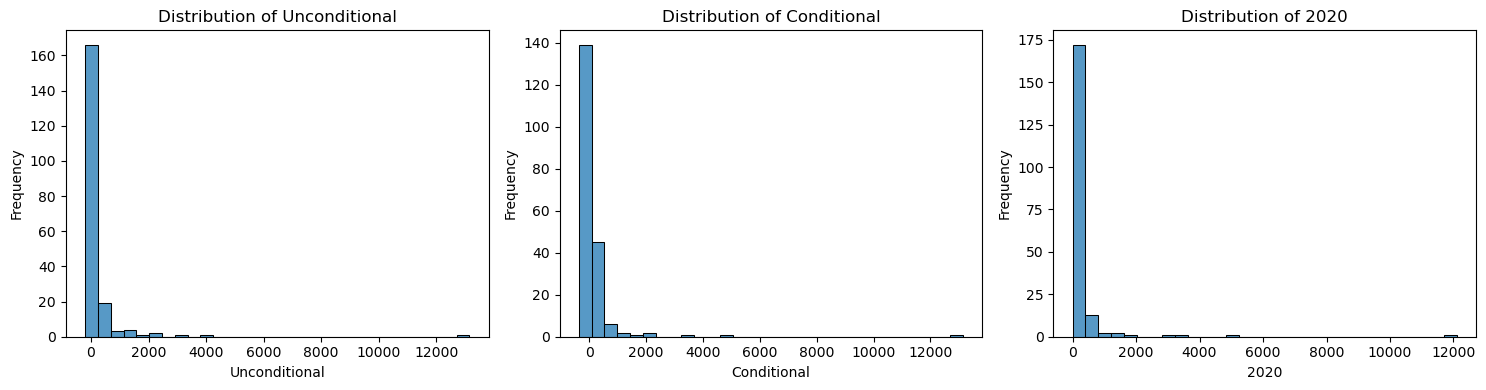

In [71]:
edau.plot_column_distributions(ndc_ref, ["Unconditional", "Conditional", "2020"], kde=False)

In [72]:
ndc_ref["ISO"].unique()

array(['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS',
       'AZE', 'BDI', 'BEN', 'BFA', 'BGD', 'BHR', 'BHS', 'BIH', 'BLR',
       'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN',
       'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COK', 'COL',
       'COM', 'CPV', 'CRI', 'CUB', 'DJI', 'DMA', 'DOM', 'DZA', 'ECU',
       'EGY', 'ERI', 'ETH', 'EUU', 'FJI', 'FSM', 'GAB', 'GBR', 'GEO',
       'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRD', 'GTM', 'GUY', 'HND',
       'HTI', 'IDN', 'IND', 'IRN', 'IRQ', 'ISL', 'ISR', 'JAM', 'JOR',
       'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT',
       'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'MAR',
       'MCO', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI', 'MMR',
       'MNE', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER',
       'NGA', 'NIC', 'NIU', 'NOR', 'NPL', 'NRU', 'NZL', 'OMN', 'PAK',
       'PAN', 'PER', 'PHL', 'PLW', 'PNG', 'PRK', 'PRY', 'PSE', 'QAT',
       'RUS', 'RWA',

In [73]:
ndc_ref[ndc_ref.Country=="Japan"]

,Country,ISO,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20
72,Japan,JPN,760.3,760.3,1058.627502,-0.281806,-0.281806


In [74]:
run_id = 1773188058
log_emissions_field_name = "x_log_signed_con_edgar_ghg_mt"


base_df = pd.read_csv(os.path.join(TRAINING_DIR_PATH, f"training_df_{run_id}.csv"))

base_df_filtered = base_df[base_df["year"] == 2020][["iso_alpha_3", log_emissions_field_name]]
base_df_filtered["2020_edgar_ghg_mt"] = np.expm1(base_df_filtered[log_emissions_field_name])
base_df_filtered.head()


,iso_alpha_3,x_log_signed_con_edgar_ghg_mt,2020_edgar_ghg_mt
15,AFG,3.372478,28.150674
33,AGO,4.286101,71.682513
51,ALB,2.181897,7.863104
69,ARG,5.886175,359.025664
87,ARM,2.379782,9.802551


In [75]:
ndc_ref_base = ndc_ref.merge(base_df_filtered, left_on="ISO", right_on="iso_alpha_3", how="right")
ndc_ref_base["unconditional_target"] = (1 + ndc_ref_base["Unconditional_b20"]) * ndc_ref_base["2020_edgar_ghg_mt"]
ndc_ref_base["conditional_target"] = (1 + ndc_ref_base["Conditional_b20"]) * ndc_ref_base["2020_edgar_ghg_mt"]
ndc_ref_base

,Country,ISO,Unconditional,Conditional,2020,Unconditional_b20,Conditional_b20,iso_alpha_3,x_log_signed_con_edgar_ghg_mt,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,51.7,45.5,34.309517,0.506871,0.326163,AFG,3.372478,28.150674,42.419422,37.332373
1,Angola,AGO,27.6,-1.4,133.309538,-0.792963,-1.010502,AGO,4.286101,71.682513,14.840929,-0.752801
2,Albania,ALB,12.0,12.0,8.351838,0.436810,0.436810,ALB,2.181897,7.863104,11.297782,11.297782
3,Argentina,ARG,349.0,349.0,390.839275,-0.107050,-0.107050,ARG,5.886175,359.025664,320.592031,320.592031
4,Armenia,ARM,10.6,15.1,10.087433,0.050812,0.496912,ARM,2.379782,9.802551,10.300642,14.673556
...,...,...,...,...,...,...,...,...,...,...,...,...
131,United States of America,USA,3251.2,3251.2,5229.090880,-0.378248,-0.378248,USA,8.633476,5615.567418,3491.492727,3491.492727
132,Uzbekistan,UZB,184.2,353.8,181.190158,0.016612,0.952645,UZB,5.360642,211.861638,215.380980,413.690503
133,South Africa,ZAF,430.7,385.0,552.048280,-0.219815,-0.302597,ZAF,6.314389,551.464312,430.244397,384.592739
134,Zambia,ZMB,72.5,51.0,96.540263,-0.249018,-0.471723,ZMB,3.399656,28.953793,21.743778,15.295623


In [76]:
# ndc_ref_base.to_clipboard(index=False)

In [77]:
ndc_ref_base = ndc_ref_base.dropna()
ndc_ref_base = ndc_ref_base[
    [
        "Country",
        "iso_alpha_3",
        "2020_edgar_ghg_mt",
        "unconditional_target",
        "conditional_target"
    ]
]
ndc_ref_base.head()

,Country,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,28.150674,42.419422,37.332373
1,Angola,AGO,71.682513,14.840929,-0.752801
2,Albania,ALB,7.863104,11.297782,11.297782
3,Argentina,ARG,359.025664,320.592031,320.592031
4,Armenia,ARM,9.802551,10.300642,14.673556


In [78]:
ndc_ref_base.to_clipboard(index=False)

In [79]:
from typing import Iterable, List, Optional, Union


def ndc_summary(
    projected_df: pd.DataFrame,
    ndc_df: pd.DataFrame,
    year: int = 2030,
    value_col: str = "con_edgar_ghg_mt_hp_trend",
    cap_cols: Union[str, List[str]] = "Unconditional",
    iso_col: str = "iso_alpha_3",
    scenario_col: str = "future_id",
    year_col: str = "year",
    keep_cap_values: bool = False,
) -> pd.DataFrame:
    """
    Merge modeled futures with NDC caps and summarize, by ISO, the share of futures
    that meet each cap in a given target year.

    Parameters
    ----------
    projected_df : pd.DataFrame
        Must include columns: [iso_col, scenario_col, year_col, value_col]
    ndc_df : pd.DataFrame
        Must include columns: [iso_col] + cap_cols
        Where each cap column is a numeric cap/threshold for the given ISO.
    year : int
        Target year to evaluate.
    value_col : str
        Column in projected_df with modeled emissions/value to compare to cap.
    cap_cols : str | list[str]
        One or more cap columns in ndc_df (e.g., ["Unconditional", "Conditional"]).
    iso_col : str
        ISO3 column name in both DataFrames.
    scenario_col : str
        Scenario/future identifier column in projected_df (used to count unique futures).
    year_col : str
        Year column in projected_df.
    keep_cap_values : bool
        If True, also return the cap values per ISO in the output.

    Returns
    -------
    pd.DataFrame
        One row per ISO (and per cap if you keep the long format—here we return wide):
          - iso_col
          - meets_ndc__<cap_col> : share of futures meeting that cap
          - n_futures            : number of unique futures evaluated (same across caps, after filtering)
        Optionally:
          - cap__<cap_col>       : the (deduped) cap value per ISO
    """
    # Normalize cap_cols to list
    if isinstance(cap_cols, str):
        cap_cols = [cap_cols]
    cap_cols = list(cap_cols)

    # Basic column checks (fail fast with helpful message)
    needed_proj = {iso_col, scenario_col, year_col, value_col}
    missing_proj = needed_proj - set(projected_df.columns)
    if missing_proj:
        raise KeyError(f"projected_df missing columns: {sorted(missing_proj)}")

    needed_ndc = {iso_col, *cap_cols}
    missing_ndc = needed_ndc - set(ndc_df.columns)
    if missing_ndc:
        raise KeyError(f"ndc_df missing columns: {sorted(missing_ndc)}")

    # Deduplicate NDC caps per ISO (keep first)
    ndc_min = (
        ndc_df[[iso_col] + cap_cols]
        .drop_duplicates(subset=[iso_col], keep="first")
        .copy()
    )

    # Merge caps onto projections
    full = projected_df.merge(ndc_min, on=iso_col, how="left")

    # Filter to target year and require at least one cap present
    df_y = full.loc[full[year_col].eq(year)].copy()
    df_y[value_col] = pd.to_numeric(df_y[value_col], errors="coerce")

    # Coerce caps to numeric
    for c in cap_cols:
        df_y[c] = pd.to_numeric(df_y[c], errors="coerce")

    # If value is NaN, it can't be evaluated; if all caps NaN, drop row
    df_y = df_y.loc[df_y[value_col].notna()].copy()
    df_y = df_y.loc[df_y[cap_cols].notna().any(axis=1)].copy()

    # Count futures per ISO (after year/value filter)
    base_counts = (
        df_y.groupby(iso_col, as_index=False)
        .agg(n_futures=(scenario_col, "nunique"))
    )

    # Compute "meets" per cap and aggregate mean by ISO
    meets_parts = []
    for c in cap_cols:
        tmp = df_y.loc[df_y[c].notna(), [iso_col, scenario_col, value_col, c]].copy()
        tmp["meets"] = tmp[value_col] < tmp[c]
        agg = (
            tmp.groupby(iso_col, as_index=False)
            .agg(**{f"meets_ndc_{c}": ("meets", "mean")})
        )
        meets_parts.append(agg)

    # Merge all cap results together
    out = base_counts
    for part in meets_parts:
        out = out.merge(part, on=iso_col, how="left")

    # Optionally include cap values (deduped) as columns
    if keep_cap_values:
        cap_wide = ndc_min.rename(columns={c: f"cap_{c}" for c in cap_cols})
        out = out.merge(cap_wide, on=iso_col, how="left")

    return out

In [80]:
projected_df = pd.read_parquet(
    os.path.join(
        POST_PROCESSING_DIR_PATH,
        f"post_processed_projected_emissions_{run_id}.parquet"
    )
)

projected_df.head()

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [81]:
target_evaluation_df = ndc_summary(
    projected_df=projected_df,
    ndc_df=ndc_ref_base,
    cap_cols=["unconditional_target", "conditional_target"],
    year=2030
)

target_evaluation_df.head()

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,949,0.416228,0.321391
1,AGO,980,0.000000,0.000000
2,ALB,991,1.000000,1.000000
3,ARG,998,0.006012,0.006012
4,ARM,992,0.563508,1.000000


In [82]:
# Filter out outliers
outlier_isos = [
    "NAM",
    "AGO",
    "ZAF",
    "QAT",
    "LSO",
    "EST",
    "NOR",
    "OMN",
    "COL",
    "SOM",
    "LBN,"
    "MDA"

]

target_evaluation_df = target_evaluation_df[~target_evaluation_df["iso_alpha_3"].isin(outlier_isos)]
target_evaluation_df.head()

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,949,0.416228,0.321391
2,ALB,991,1.000000,1.000000
3,ARG,998,0.006012,0.006012
4,ARM,992,0.563508,1.000000
5,AUT,992,0.000000,0.000000


In [83]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_ndc_meets_histograms(
    df: pd.DataFrame,
    iso_col: str = "iso_alpha_3",
    unconditional_col: str = "meets_ndc_unconditional_target",
    conditional_col: str = "meets_ndc_conditional_target",
    bins: int = 20,
    figsize=(10, 4),
):
    """
    Plot side-by-side histograms of NDC meet shares (unconditional vs conditional).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing ISO rows and meets_ndc columns.
    iso_col : str
        ISO column (not used in plotting, just for validation).
    unconditional_col : str
        Column with unconditional meet shares (0–1).
    conditional_col : str
        Column with conditional meet shares (0–1).
    bins : int
        Number of histogram bins.
    figsize : tuple
        Figure size.
    """

    # Basic validation
    for col in [unconditional_col, conditional_col]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame")

    data_uncond = df[unconditional_col].dropna()
    data_cond   = df[conditional_col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Unconditional
    axes[0].hist(data_uncond, bins=bins)
    axes[0].set_title("Meets NDC – Unconditional")
    axes[0].set_xlabel("Share of futures meeting NDC")
    axes[0].set_ylabel("Number of countries")
    axes[0].set_xlim(0, 1)

    # Conditional
    axes[1].hist(data_cond, bins=bins)
    axes[1].set_title("Meets NDC – Conditional")
    axes[1].set_xlabel("Share of futures meeting NDC")
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

In [84]:
target_evaluation_df[target_evaluation_df.iso_alpha_3 == "COL"]

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target


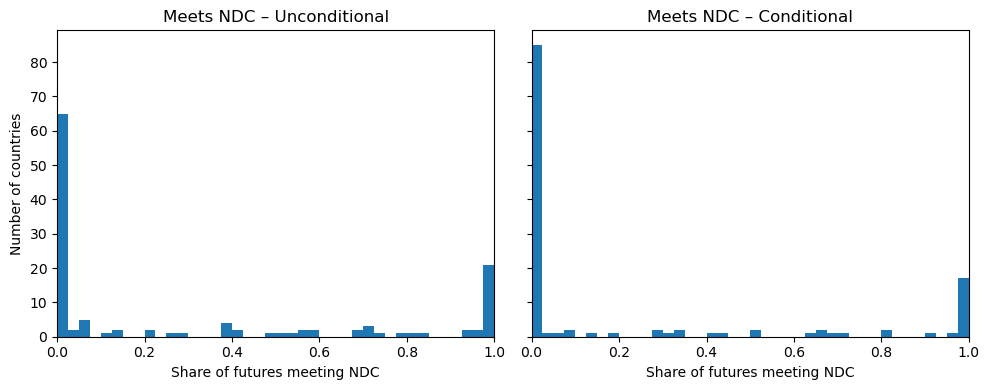

In [85]:
plot_ndc_meets_histograms(
    df=target_evaluation_df,
    bins=40
)

In [86]:
target_evaluation_df.describe()

,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
count,126.000000,126.000000,126.000000
mean,989.150794,0.314200,0.222296
std,7.006360,0.405740,0.374404
min,949.000000,0.000000,0.000000
25%,987.250000,0.000000,0.000000
50%,991.000000,0.017135,0.000000
75%,993.000000,0.697989,0.326311
max,1000.000000,1.000000,1.000000


In [87]:
country_list_df = ndc_ref_base[["Country", "iso_alpha_3"]].drop_duplicates()
country_list_df

,Country,iso_alpha_3
0,Afghanistan,AFG
1,Angola,AGO
2,Albania,ALB
3,Argentina,ARG
4,Armenia,ARM
...,...,...
131,United States of America,USA
132,Uzbekistan,UZB
133,South Africa,ZAF
134,Zambia,ZMB


In [88]:
projected_df

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918
...,...,...,...,...
1210801,id_ZWE_998,ZWE,2026,40.372988
1210802,id_ZWE_998,ZWE,2027,42.264529
1210803,id_ZWE_998,ZWE,2028,44.129562
1210804,id_ZWE_998,ZWE,2029,46.128465


In [89]:
import pandas as pd
import numpy as np


def compute_2030_q1_mean(
    df: pd.DataFrame,
    value_col: str = "con_edgar_ghg_mt_hp_trend",
    year_col: str = "year",
    iso_col: str = "iso_alpha_3",
    target_year: int = 2030,
):
    """
    For each country, compute the mean of the lowest quartile (Q1)
    of 2030 emissions across futures.
    """

    # Filter to 2030
    df_2030 = df[df[year_col] == target_year].copy()

    # Ensure numeric
    df_2030[value_col] = pd.to_numeric(df_2030[value_col], errors="coerce")

    def q1_mean(x):
        q1_cutoff = np.quantile(x, 0.25)
        return x[x <= q1_cutoff].mean()

    out = (
        df_2030
        .groupby(iso_col)[value_col]
        .apply(q1_mean)
        .reset_index(name="2030_q1_mean_value")
    )

    return out

In [90]:
q1_mean_2030_df = compute_2030_q1_mean(
    projected_df
)

q1_mean_2030_df.head()

,iso_alpha_3,2030_q1_mean_value
0,AFG,24.367323
1,AGO,63.154899
2,ALB,0.599486
3,ARG,364.270168
4,ARM,8.637496


In [91]:
ndc_ref_base

,Country,iso_alpha_3,2020_edgar_ghg_mt,unconditional_target,conditional_target
0,Afghanistan,AFG,28.150674,42.419422,37.332373
1,Angola,AGO,71.682513,14.840929,-0.752801
2,Albania,ALB,7.863104,11.297782,11.297782
3,Argentina,ARG,359.025664,320.592031,320.592031
4,Armenia,ARM,9.802551,10.300642,14.673556
...,...,...,...,...,...
131,United States of America,USA,5615.567418,3491.492727,3491.492727
132,Uzbekistan,UZB,211.861638,215.380980,413.690503
133,South Africa,ZAF,551.464312,430.244397,384.592739
134,Zambia,ZMB,28.953793,21.743778,15.295623


In [92]:
target_evaluation_df

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target
0,AFG,949,0.416228,0.321391
2,ALB,991,1.000000,1.000000
3,ARG,998,0.006012,0.006012
4,ARM,992,0.563508,1.000000
5,AUT,992,0.000000,0.000000
...,...,...,...,...
130,URY,988,0.846154,0.653846
131,USA,992,0.000000,0.000000
132,UZB,995,0.003015,1.000000
134,ZMB,992,0.000000,0.000000


In [93]:
target_evaluation_df.merge(ndc_ref_base, how="left", on="iso_alpha_3").merge(q1_mean_2030_df, how="left", on="iso_alpha_3").to_clipboard(index=False)

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_share_countries_above_probability(
    df: pd.DataFrame,
    prob_col: str,
    thresholds=None,
    figsize=(6, 4),
):
    """
    Plot share of countries whose probability of meeting NDC >= threshold.

    x-axis: probability threshold (0–1)
    y-axis: share of countries meeting or exceeding that probability
    """

    p = df[prob_col].dropna().values
    N = len(p)

    if thresholds is None:
        thresholds = np.linspace(0, 1, 200)

    shares = [(p >= t).sum() / N for t in thresholds]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(thresholds, shares)

    ax.set_xlabel("Probability threshold to meet NDC")
    ax.set_ylabel("Share of countries ≥ threshold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.grid()

    plt.tight_layout()
    plt.show()

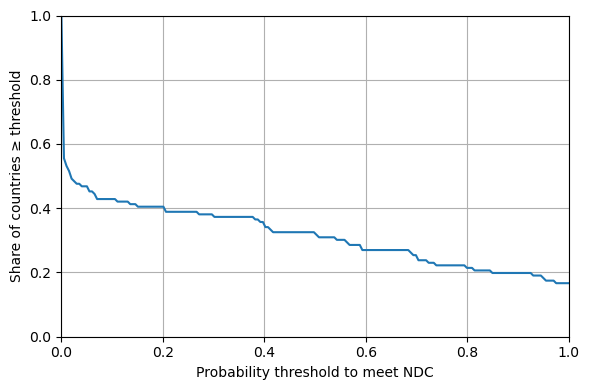

In [95]:
plot_share_countries_above_probability(
    target_evaluation_df,
    prob_col="meets_ndc_unconditional_target"
)